In [1]:
from google.colab import files

uploaded = files.upload()


Saving CMAPSSData.zip to CMAPSSData.zip


In [2]:
import zipfile

with zipfile.ZipFile("CMAPSSData.zip", "r") as zip_ref:
    zip_ref.extractall("CMAPSS")



In [3]:
import os

os.listdir("CMAPSS")

['test_FD004.txt',
 'RUL_FD004.txt',
 'RUL_FD002.txt',
 'train_FD002.txt',
 'test_FD002.txt',
 'train_FD004.txt',
 'test_FD001.txt',
 'train_FD003.txt',
 'RUL_FD003.txt',
 'readme.txt',
 'Damage Propagation Modeling.pdf',
 'train_FD001.txt',
 'RUL_FD001.txt',
 'test_FD003.txt']

In [4]:
import pandas as pd
import numpy as np


In [6]:
train = pd.read_csv(
    "/content/CMAPSS/train_FD001.txt",
    sep=r"\s+",
    header=None
)

train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train.shape

(20631, 26)

In [8]:
train.head()


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [9]:
columns = (
    ['engine_id', 'cycle']
    + [f'op_setting_{i}' for i in range(1,4)]
    + [f'sensor_{i}' for i in range(1,22)]
)

train.columns = columns

In [10]:
train.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')

In [11]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [12]:
train.isnull().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [13]:
train[train.engine_id == 1].head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [14]:
max_cycles = train.groupby('engine_id')['cycle'].max()

max_cycles.head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


In [15]:
max_cycles = max_cycles.reset_index()

max_cycles.columns = [
    'engine_id',
    'max_cycle'
]

max_cycles.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [16]:
train = train.merge(
    max_cycles,
    on='engine_id',
    how='left'
)

train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [17]:
train['RUL'] = (
    train['max_cycle']
    - train['cycle']
)

train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [25]:
# train.drop(
#     'max_cycle',
#     axis=1,
#     inplace=True
# )

# I have run this code to remove the HELPERFILE -> max_cycle

In [26]:
train[
    train.engine_id == 1
][['cycle','RUL']].head()

,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187


In [27]:
train[
    train.engine_id == 1
][['cycle','RUL']].tail()

,cycle,RUL
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [28]:
from sklearn.preprocessing import MinMaxScaler

features = train.drop(columns=["engine_id", "cycle", "RUL"])

scaler = MinMaxScaler()

train[features.columns] = scaler.fit_transform(features)

train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187


In [29]:
sequence_length = 30

In [30]:
feature_cols = [
    col for col in train.columns
    if col not in ["engine_id", "cycle", "RUL", "max_cycle"]
]

In [31]:
X = []
y = []

In [33]:
for engine_id in train.engine_id.unique():

    engine_data = train[train.engine_id == engine_id]

    data_array = engine_data[feature_cols].values
    rul_array = engine_data["RUL"].values

    for i in range(len(engine_data) - sequence_length):

        X.append(data_array[i:i + sequence_length])

        y.append(rul_array[i + sequence_length])

In [34]:
X = np.array(X)
y = np.array(y)

In [35]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (17631, 30, 24)
y Shape: (17631,)


In [36]:
X.shape
y.shape

(17631,)

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (14104, 30, 24)
X_val: (3527, 30, 24)
y_train: (14104,)
y_val: (3527,)


In [41]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [42]:
model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(30, 24)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,745 (139.63 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [46]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 8872.6611 - mae: 74.2071 - val_loss: 5178.0542 - val_mae: 55.7067
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 4203.1665 - mae: 51.5743 - val_loss: 3736.6965 - val_mae: 49.8425
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 3888.5613 - mae: 50.6890 - val_loss: 3733.7314 - val_mae: 49.9218
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 3891.3811 - mae: 50.8730 - val_loss: 3734.9556 - val_mae: 49.8659
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3892.5757 - mae: 50.7932 - val_loss: 3735.3110 - val_mae: 49.8551
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 3894.7915 - mae: 50.7830 - val_loss: 3734.1616 - val_mae: 49.8788
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 3215.3357 - mae: 44.2231 - val_loss: 1537.1246 - val_mae: 27.0315
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 1586.6614 - mae: 28.6159 - val_loss: 1300.2037

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [48]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 1058.3303 - mae: 22.2300 - val_loss: 936.3349 - val_mae: 20.1349
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 1030.4513 - mae: 21.9235 - val_loss: 917.0779 - val_mae: 20.4149
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 1015.9069 - mae: 21.5837 - val_loss: 945.6747 - val_mae: 21.7979
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 1039.0909 - mae: 21.8640 - val_loss: 966.9443 - val_mae: 19.9172
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 999.3057 - mae: 21.5710 - val_loss: 915.5989 - val_mae: 20.1506
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 1002.9764 - mae: 21.5214 - val_loss: 915.3285 - val_mae: 20.3608
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 1020.5871 - mae: 21.6621 - val_loss: 920.5970 - val_mae: 20.4052
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 1008.2592 - mae: 21.6393 - val_loss: 931.0797 - val_mae:

In [49]:
predictions = model.predict(X_val)

print("Predictions Shape:", predictions.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Predictions Shape: (3527, 1)


In [50]:
for i in range(10):
    print(
        "Actual:", y_val[i],
        "Predicted:", predictions[i][0]
    )

Actual: 148 Predicted: 135.60666
Actual: 157 Predicted: 182.90071
Actual: 128 Predicted: 167.16806
Actual: 120 Predicted: 150.64064
Actual: 87 Predicted: 66.007545
Actual: 135 Predicted: 161.4426
Actual: 38 Predicted: 43.006096
Actual: 164 Predicted: 143.7877
Actual: 105 Predicted: 141.67894
Actual: 106 Predicted: 121.365524


In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, predictions)

rmse = np.sqrt(
    mean_squared_error(y_val, predictions)
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 20.158803939819336
RMSE: 29.84403529804731


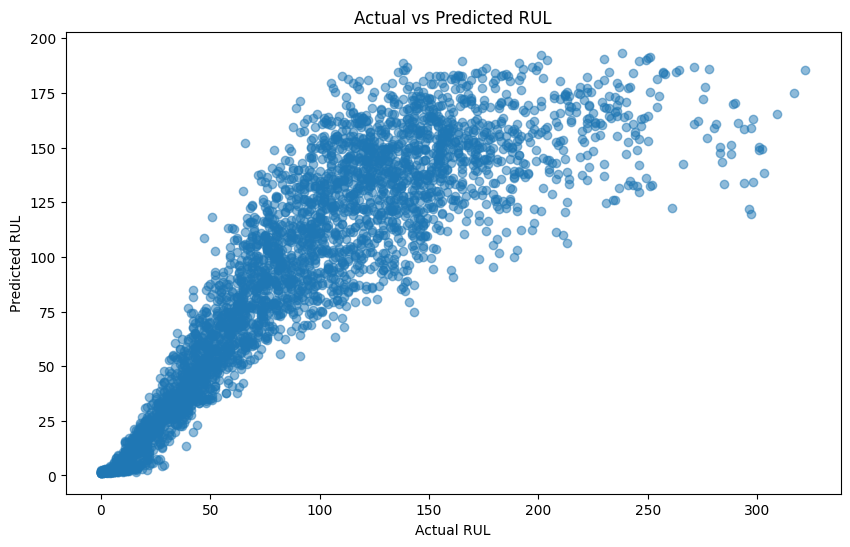

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_val,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [54]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 983.3494 - mae: 21.2724 - val_loss: 917.3875 - val_mae: 19.5999
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 991.3207 - mae: 21.2195 - val_loss: 900.8176 - val_mae: 20.5605
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 971.6486 - mae: 20.9721 - val_loss: 917.2130 - val_mae: 19.8982
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 978.8356 - mae: 21.1693 - val_loss: 895.2742 - val_mae: 20.1607
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 982.8378 - mae: 21.2577 - val_loss: 875.6171 - val_mae: 19.7268
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 974.5675 - mae: 20.9750 - val_loss: 904.2692 - val_mae: 20.2286
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 963.3358 - mae: 20.9089 - val_loss: 893.8900 - val_mae: 20.6859
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 966.0675 - mae: 20.9247 - val_loss: 917.2964 - val_mae: 20.0876

In [55]:
predictions = model.predict(X_val)

print("Predictions Shape:", predictions.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Predictions Shape: (3527, 1)


In [56]:
for i in range(10):
    print(
        "Actual:", y_val[i],
        "Predicted:", predictions[i][0]
    )

Actual: 148 Predicted: 131.64166
Actual: 157 Predicted: 191.09392
Actual: 128 Predicted: 183.2407
Actual: 120 Predicted: 143.32486
Actual: 87 Predicted: 61.52817
Actual: 135 Predicted: 158.49446
Actual: 38 Predicted: 40.533855
Actual: 164 Predicted: 140.562
Actual: 105 Predicted: 144.57928
Actual: 106 Predicted: 112.23883


In [57]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, predictions)

rmse = np.sqrt(
    mean_squared_error(y_val, predictions)
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 19.392419815063477
RMSE: 28.68889566321785


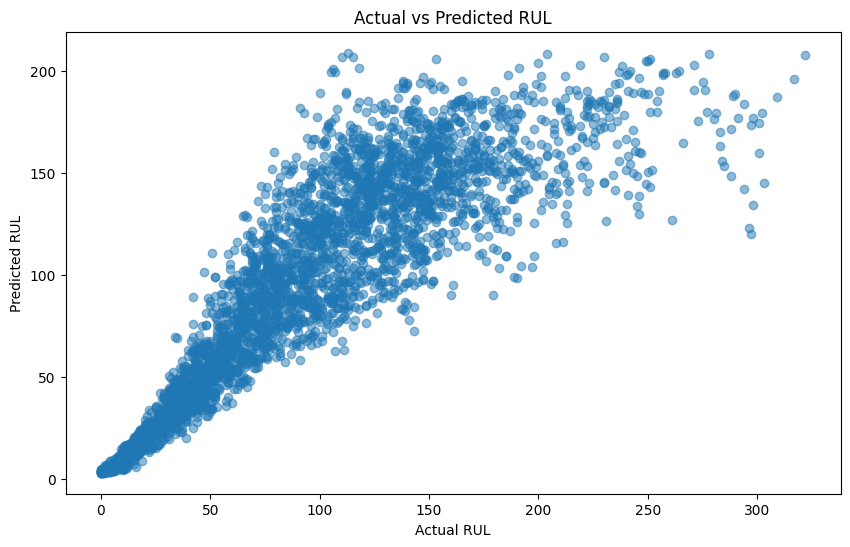

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_val,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 970.6635 - mae: 21.0138 - val_loss: 857.1131 - val_mae: 19.0548
Epoch 2/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - loss: 934.3536 - mae: 20.7073 - val_loss: 873.3123 - val_mae: 19.1173
Epoch 3/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 921.8981 - mae: 20.5194 - val_loss: 848.5252 - val_mae: 19.9564
Epoch 4/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 915.5172 - mae: 20.4517 - val_loss: 844.3792 - val_mae: 19.5583
Epoch 5/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 909.4351 - mae: 20.3752 - val_loss: 900.6564 - val_mae: 19.3918
Epoch 6/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 894.6492 - mae: 20.2209 - val_loss: 855.0642 - val_mae: 18.9885
Epoch 7/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 878.2496 - mae: 20.0292 - val_loss: 814.8555 - val_mae: 18.7076
Epoch 8/100
441/441 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 888.7056 - mae: 20.1684 - val_loss: 788.8033 - v

In [61]:
predictions = model.predict(X_val)

print("Predictions Shape:", predictions.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Predictions Shape: (3527, 1)


In [62]:
for i in range(10):
    print(
        "Actual:", y_val[i],
        "Predicted:", predictions[i][0]
    )

Actual: 148 Predicted: 131.24734
Actual: 157 Predicted: 182.7181
Actual: 128 Predicted: 170.1431
Actual: 120 Predicted: 137.51787
Actual: 87 Predicted: 60.873608
Actual: 135 Predicted: 148.15248
Actual: 38 Predicted: 45.090782
Actual: 164 Predicted: 134.92645
Actual: 105 Predicted: 156.88033
Actual: 106 Predicted: 99.39305


In [63]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, predictions)

rmse = np.sqrt(
    mean_squared_error(y_val, predictions)
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 18.654014587402344
RMSE: 27.86466425708654


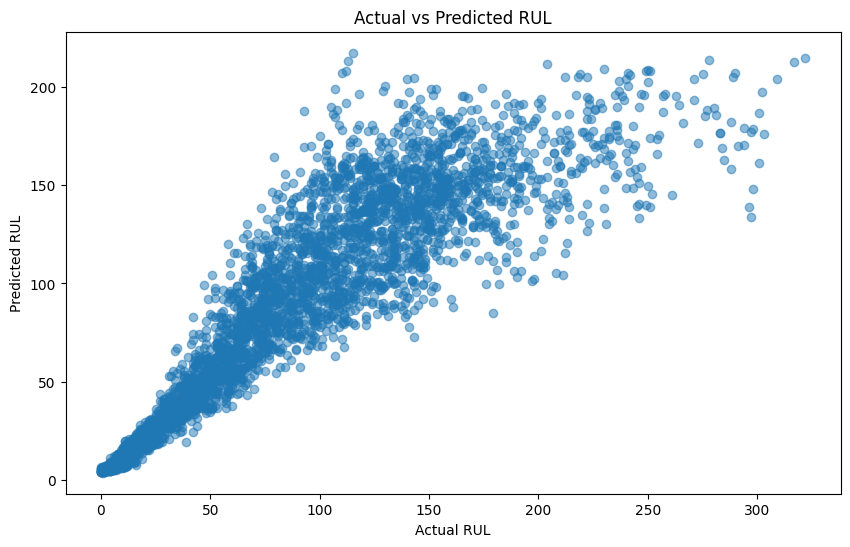

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_val,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [66]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 820.9535 - mae: 19.2652 - val_loss: 782.7115 - val_mae: 18.3663
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 819.8668 - mae: 19.2997 - val_loss: 795.0469 - val_mae: 19.4828
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 816.4376 - mae: 19.2836 - val_loss: 759.6323 - val_mae: 18.8700
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 808.5615 - mae: 19.1350 - val_loss: 760.5910 - val_mae: 18.2774
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 809.0043 - mae: 19.2469 - val_loss: 761.1981 - val_mae: 18.2332
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 809.0494 - mae: 19.1888 - val_loss: 831.9382 - val_mae: 18.4637


In [67]:
predictions = model.predict(X_val)

print("Predictions Shape:", predictions.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Predictions Shape: (3527, 1)


In [68]:
for i in range(10):
    print(
        "Actual:", y_val[i],
        "Predicted:", predictions[i][0]
    )

Actual: 148 Predicted: 135.62085
Actual: 157 Predicted: 193.31096
Actual: 128 Predicted: 177.72467
Actual: 120 Predicted: 140.79088
Actual: 87 Predicted: 67.9691
Actual: 135 Predicted: 149.90616
Actual: 38 Predicted: 49.493694
Actual: 164 Predicted: 138.5995
Actual: 105 Predicted: 160.16768
Actual: 106 Predicted: 95.024055


In [69]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, predictions)

rmse = np.sqrt(
    mean_squared_error(y_val, predictions)
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 18.870046615600586
RMSE: 27.561427089024143


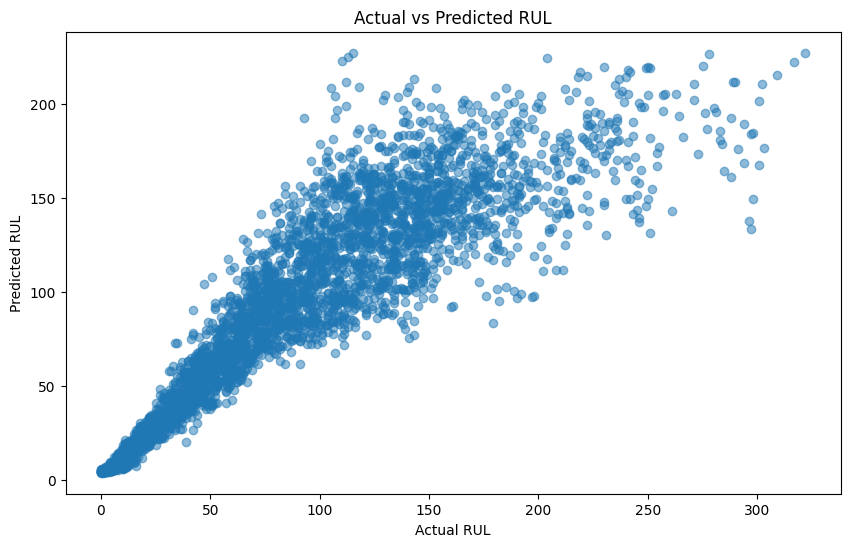

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_val,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

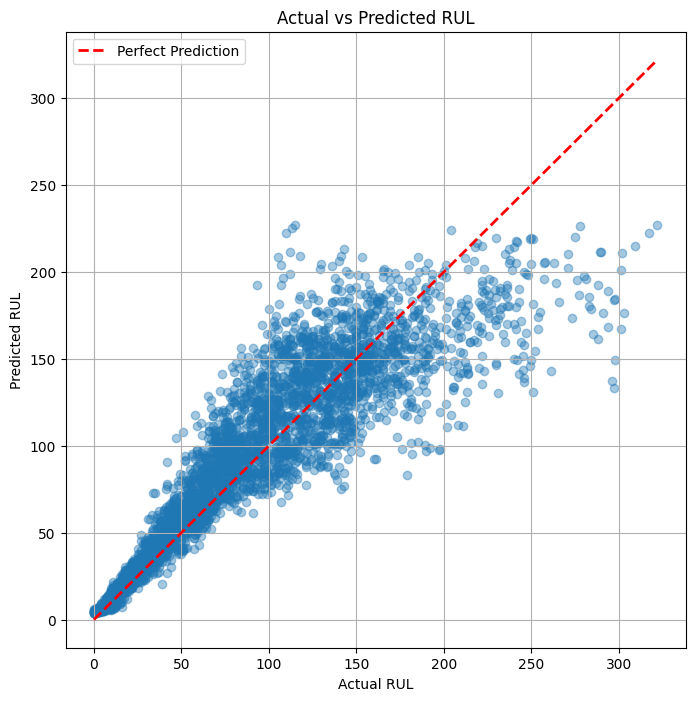

In [73]:
plt.figure(figsize=(8,8))

plt.scatter(y_val, predictions, alpha=0.4)

max_val = max(y_val)

plt.plot(
    [0, max_val],
    [0, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.legend()
plt.grid(True)

plt.show()

In [77]:
model.save("best_lstm_rul.keras")

In [78]:
import os

os.path.exists("best_lstm_rul.keras")

True

In [79]:
from google.colab import files

files.download("best_lstm_rul.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
from tensorflow.keras.models import load_model

loaded_model = load_model("best_lstm_rul.keras")

In [81]:
pred = loaded_model.predict(X_val[:5])

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
[[135.62085]
 [193.31096]
 [177.72467]
 [140.79088]
 [ 67.9691 ]]


In [82]:
# Conclusion

# This project successfully developed an LSTM-based predictive maintenance model for Remaining Useful Life (RUL) estimation using the NASA C-MAPSS FD001 turbofan engine dataset. The raw sensor measurements and operational settings were preprocessed through data cleaning, normalization, RUL generation, and sequence creation to capture the temporal degradation behavior of aircraft engines. A stacked LSTM architecture consisting of two LSTM layers, dropout regularization, and fully connected layers was trained to learn degradation patterns from historical engine data.

# The model achieved a Mean Absolute Error (MAE) of approximately 18.65 cycles and a Root Mean Squared Error (RMSE) of approximately 27.86 cycles, demonstrating good predictive capability for engine health monitoring. Evaluation through Actual vs Predicted and Residual plots showed that the model accurately predicted low and medium RUL values, while larger prediction errors occurred for engines with very high remaining life, indicating a tendency to underestimate highly healthy engines.

# Despite this limitation, the model successfully captured the overall degradation trend and exhibited good generalization without significant overfitting. Furthermore, the trained model was saved, reloaded, and used for inference, demonstrating its readiness for deployment in real-world predictive maintenance applications. Overall, the developed LSTM framework provides an effective baseline solution for aircraft engine prognostics and can be further enhanced through advanced architectures, feature engineering, and hyperparameter optimization to achieve even higher prediction accuracy.
